In [41]:
import matplotlib.pyplot as plt
import os
#from utilites import read_data_from_timestep
import numpy as np
import pandas as pd
import csv


rho_ratio = '1'
v = '001'
Ux='001'

folder_path_resting = os.path.join("../data_for_plots",
                           "moving_vs_resting_bubble",
                           "line_data_rho%s_v%s_oscillating_Ux%s" % (rho_ratio, v,Ux))


frames_cm_resting = []


# n = np.arange(127, 999, 128)
# n = np.arange(127, 256, 128)
n = np.arange(500, 999, 1)

i = np.arange(len(n))

u_diff = np.empty(len(n))
rho_diff = np.empty(len(n))

diam_x_cm_resting = np.empty(len(n))   # x coordinate of the center of mass of the bubble
diam_x_cm_resting2 = np.empty(len(n))   # x coordinate of the center of mass of the bubble

for i_, n_ in zip(i, n):
    frame_cm_resting = pd.read_csv(os.path.join(folder_path_resting, "cm_resting.%d.csv" % n_), delimiter="\t")

    frames_cm_resting.append(frame_cm_resting)

    def find_diameter(pf, threshold=0.5):
        scale_factor = 1001/256  
        # paraview dumps 1001 grid points from line plot, 
        # while simluation domain is 256 
        counter = 0          
#         scale_factor = 10000/256  
#         x = np.arange(len(pf))
#         xvals = np.linspace(0, 256, 10000)
#         yinterp = np.interp(xvals, x, pf)
#         for y_ in yinterp:
#             if y_ > threshold:
#                 counter += 1
        for pf_ in pf:
            if pf_ > threshold:
                counter += 1
                
        ans = counter/scale_factor
        return ans
    
    def count(x,y, threshold=0.5):
        scale_factor = max(x)/len(x)
        counter = 1

        for y_ in y:
            if y_ > threshold:
                counter += 1

        ans = counter*scale_factor
        return ans

    def count_interpol(x,y, threshold=0.5): 
        x_max = max(x)
        n= len(x)
        xvals = np.linspace(0, x_max, 10*n)
        yinterp = np.interp(xvals, x, y)

        scale_factor =x_max/n
        counter = 1

        for y_ in y:
            if y_ > threshold:
                counter += 1

        ans = counter*scale_factor
        return ans

#     diam_x_cm_resting[i_] = find_diameter(frame_cm_resting['PhaseField'])
    
    diam_x_cm_resting[i_] = count_interpol(frame_cm_resting['Points:0'], frame_cm_resting['PhaseField'])
    diam_x_cm_resting2[i_] = find_diameter(frame_cm_resting['PhaseField'])



In [42]:
# diam_x_cm_resting[3]
print(max(frame_cm_resting['Points:0']))
print(len(frame_cm_resting['Points:0']))

print(count(frames_cm_resting[2]['Points:0'], frames_cm_resting[2]['PhaseField']))
print(count_interpol(frames_cm_resting[2]['Points:0'], frames_cm_resting[2]['PhaseField']))
print(find_diameter(frames_cm_resting[2]['PhaseField']))


256.0
1001
78.25774225774225
78.25774225774225
78.001998001998


78.001998001998

<Figure size 432x288 with 0 Axes>

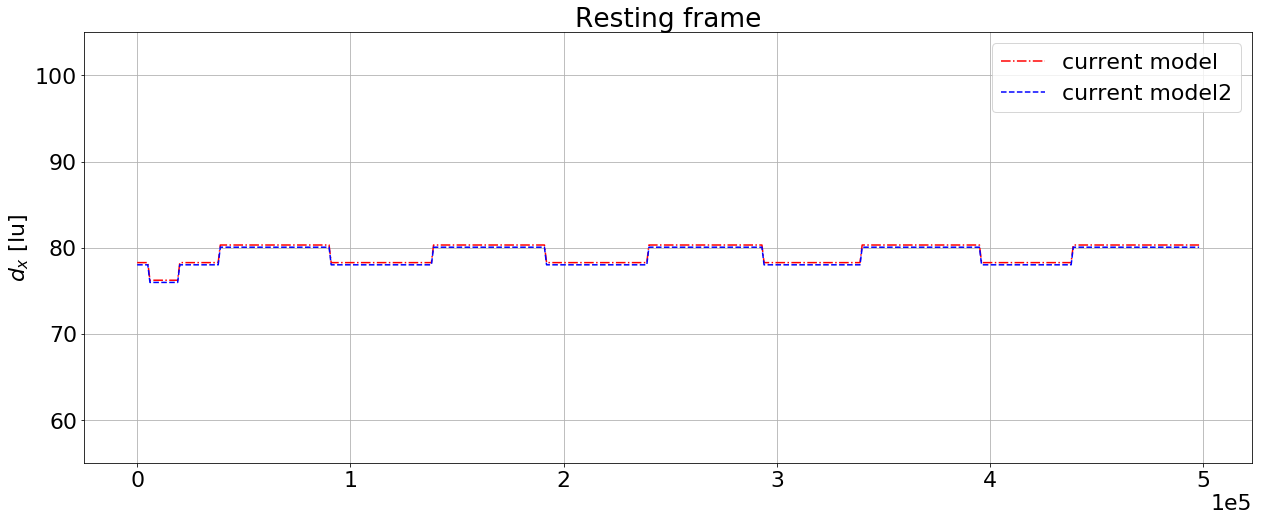

In [43]:
# make plot
plt.figure(1)
plt.figure(figsize=(18, 14))
plt.rcParams.update({'font.size': 22})

# frame_n = 1
# plt.plot(frames_cm_moving[frame_n]['arc_length'], frames_cm_moving[frame_n]['PhaseField'], color="green", marker="", linestyle="-.",  label='cm_test')
# plt.plot(frames_mrt_moving[frame_n]['arc_length'], frames_mrt_moving[frame_n]['PhaseField'], color="red", marker="", linestyle="-", label='mrt_test')

plt.subplot(211)
plt.title('Resting frame')


plt.plot(i*1E3, diam_x_cm_resting, color="red", marker="", linestyle="-.", label='current model')
plt.plot(i*1E3, diam_x_cm_resting2, color="blue", marker="", linestyle="--", label='current model2')
# plt.plot(i*1E3, diam_x_mrt_resting, color="blue", marker="", linestyle="--", label='MRT')
# plt.plot(i*1E3, diam_x_cm_moving, color="yellow", marker="", linestyle="-.", label='current model')
# plt.plot(i*1E3, diam_x_mrt_moving, color="green", marker="", linestyle="--", label='MRT')
axes = plt.gca()
# axes.set_xlim([xmin,xmax])
axes.set_ylim([55, 105])
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.ylabel(r'$d_x$ [lu]')
# plt.xlabel(r'iterations')
plt.grid(True)
plt.legend()


fig = plt.gcf()  # get current figure
plt.tight_layout()
# fig.savefig('bubble_diam_rho%s_v%s_Ma%s.png' % (rho_ratio, v, Ma))
fig.savefig('bubble_diam_rho%s_v%s_Ux%s.png' % (rho_ratio, v, Ux))
# plt.subplots_adjust(top=1.55)
plt.show()
#plt.close(fig)    # close the figure

3.141592653589793
3.141592653589793
3.141592653589793
3.141592653589793


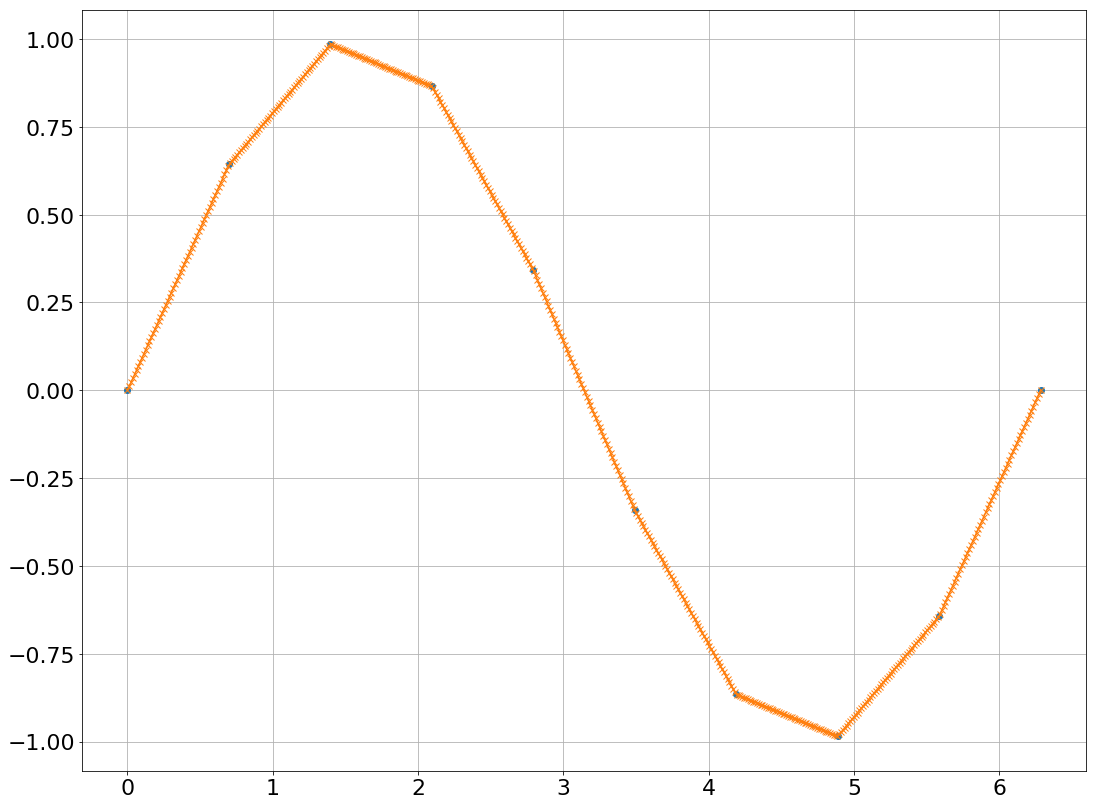

In [44]:
x = np.linspace(0, 2*np.pi, 10)
y = np.sin(x)
xvals = np.linspace(0, 2*np.pi, 500)
yinterp = np.interp(xvals, x, y)

def count(x,y, threshold=0.0):
    scale_factor = max(x)/len(x)
    counter = 1
    
    for y_ in y:
        if y_ > threshold:
            counter += 1
                
    ans = counter*scale_factor
    return ans

def count_interpol(x,y, threshold=0.0):
    
    xvals = np.linspace(0, max(x), 10*len(x))
    yinterp = np.interp(xvals, x, y)
    
    scale_factor = max(x)/len(x)
    counter = 1
    
    for y_ in y:
        if y_ > threshold:
            counter += 1
                
    ans = counter*scale_factor
    return ans

print(count(x,y))
print(count(xvals,yinterp))
print(count_interpol(x,y))
print(count_interpol(xvals,yinterp))


import matplotlib.pyplot as plt
plt.figure(figsize=(18, 14))
plt.plot(x, y, 'o')
plt.grid(True)
plt.plot(xvals, yinterp, '-x')

plt.show()
